In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [9]:
ARCH_MODE = "classifier" 
RESULTS_PATH = "results/"
file_path = os.path.join(RESULTS_PATH, f"double_ablation_predictions_{ARCH_MODE}.xlsx")

df = pd.read_excel(file_path)

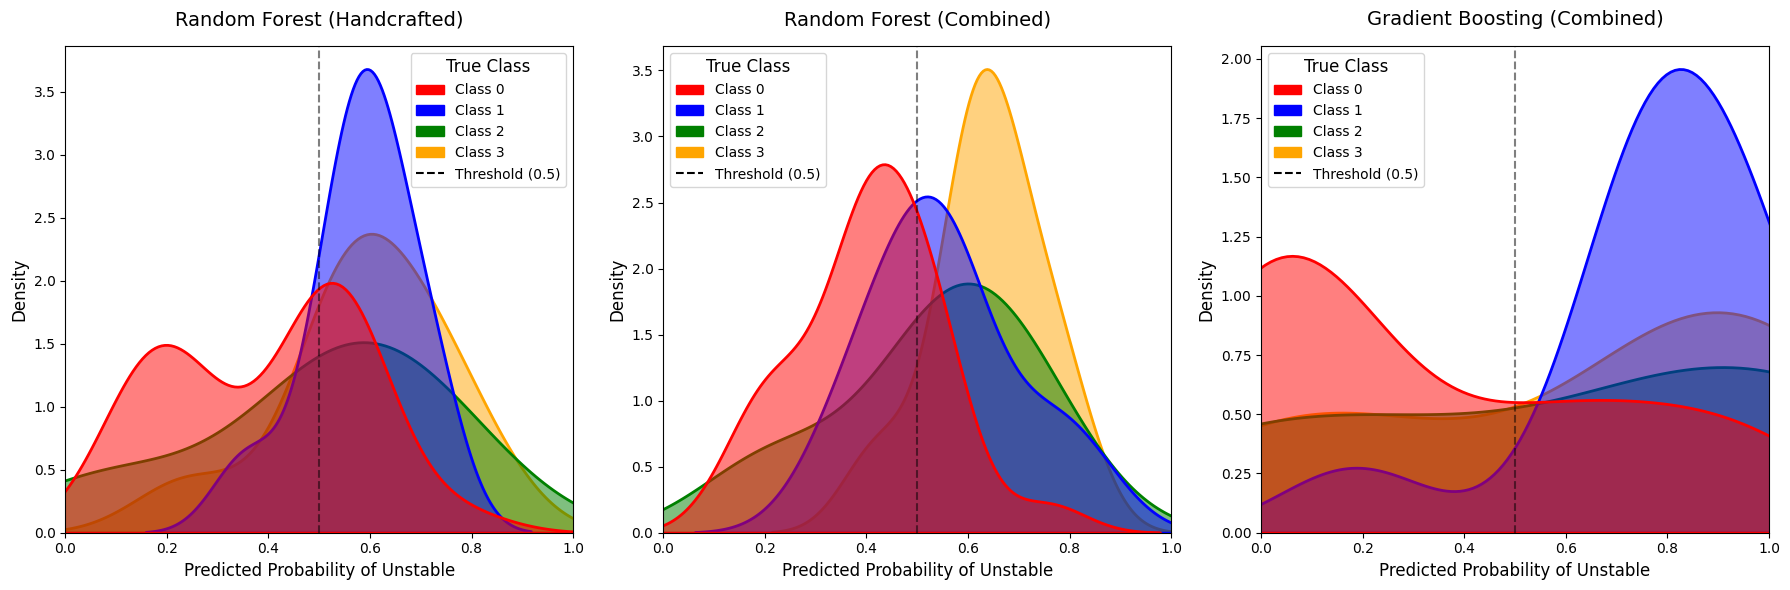

In [10]:
models_to_plot = [
    ('Random Forest (Handcrafted)', 'prob_RandomForest_Handcrafted'),
    ('Random Forest (Combined)', 'prob_RandomForest_Combined'),
    ('Gradient Boosting (Combined)', 'prob_GradientBoosting_Combined')
]

# Define explicit colors and labels for classes so the legend is stable
class_colors = {0: 'red', 1: 'blue', 2: 'green', 3: 'orange'}
class_labels = {0: 'Class 0', 1: 'Class 1', 2: 'Class 2', 3: 'Class 3'}

fig, axes = plt.subplots(1, len(models_to_plot), figsize=(6 * len(models_to_plot), 6))

for ax, (title, prob_col) in zip(axes, models_to_plot):
    if prob_col not in df.columns:
        print(f"Column {prob_col} not found.")
        continue

    # Use the explicit palette mapping so colors are controlled
    sns.kdeplot(
        data=df, x=prob_col, hue='y_true_4cls', fill=True, 
        common_norm=False, alpha=0.5, linewidth=2, ax=ax, palette=class_colors
    )

    ax.set_title(title, fontsize=14, pad=15)
    ax.set_xlabel("Predicted Probability of Unstable", fontsize=12)
    ax.set_ylabel("Density", fontsize=12)
    ax.set_xlim(0, 1)
    ax.axvline(0.5, color='black', linestyle='--', alpha=0.5, label='Threshold (0.5)')

    # Build a custom legend with specified colors and class labels
    from matplotlib.patches import Patch
    from matplotlib.lines import Line2D
    unique_classes = sorted(df['y_true_4cls'].dropna().unique())
    legend_handles = [Patch(color=class_colors.get(int(c), 'gray'), label=class_labels.get(int(c), str(c))) for c in unique_classes]
    # add threshold line to legend
    threshold_handle = Line2D([0], [0], color='black', linestyle='--')
    legend_handles.append(threshold_handle)
    legend_labels = [class_labels.get(int(c), str(c)) for c in unique_classes] + ['Threshold (0.5)']
    ax.legend(legend_handles, legend_labels, title='True Class', fontsize=10, title_fontsize=12)

plt.tight_layout()
plt.show()

y_pred_RandomForest_Combined


,Total Subjects,Misclassified,Error Rate (%)
dataset,,,
kiel,5,2,40.0
omnia_park,12,4,33.3
wearpd,24,6,25.0
pd_phone,9,2,22.2


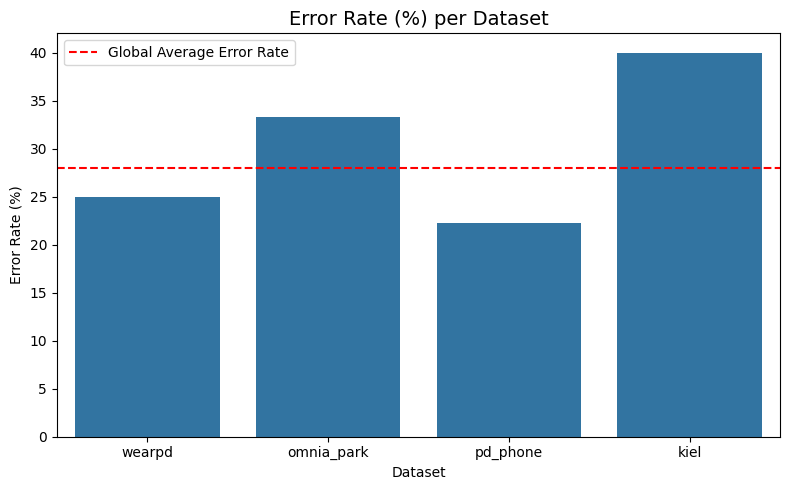

In [11]:
# Seleziona il modello "campione" per cui vuoi fare l'analisi degli errori
target_pred_col = 'y_pred_RandomForest_Combined'

if target_pred_col in df.columns:
    # Filtra i misclassificati
    errors_df = df[df['y_true'] != df[target_pred_col]]
    
    # Calcola Statistiche per Dataset
    total_per_dataset = df['dataset'].value_counts().rename("Total Subjects")
    errors_per_dataset = errors_df['dataset'].value_counts().rename("Misclassified")
    
    # Unisce in un unico DataFrame
    audit_df = pd.concat([total_per_dataset, errors_per_dataset], axis=1).fillna(0)
    audit_df['Misclassified'] = audit_df['Misclassified'].astype(int)
    audit_df['Error Rate (%)'] = (audit_df['Misclassified'] / audit_df['Total Subjects'] * 100).round(1)
    
    print(f"{target_pred_col}")
    display(audit_df.sort_values(by='Error Rate (%)', ascending=False))
    
    # Plot dell'errore per dataset
    plt.figure(figsize=(8, 5))
    sns.barplot(x=audit_df.index, y=audit_df['Error Rate (%)'])
    plt.title("Error Rate (%) per Dataset", fontsize=14)
    plt.ylabel("Error Rate (%)")
    plt.xlabel("Dataset")
    plt.axhline(audit_df['Misclassified'].sum() / audit_df['Total Subjects'].sum() * 100, 
                color='red', linestyle='--', label='Global Average Error Rate')
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print(f"Column {target_pred_col} not found.")

In [12]:
ARCH_MODE = "autoencoder" 
RESULTS_PATH = "results/"
file_path = os.path.join(RESULTS_PATH, f"double_ablation_predictions_{ARCH_MODE}.xlsx")

df = pd.read_excel(file_path)

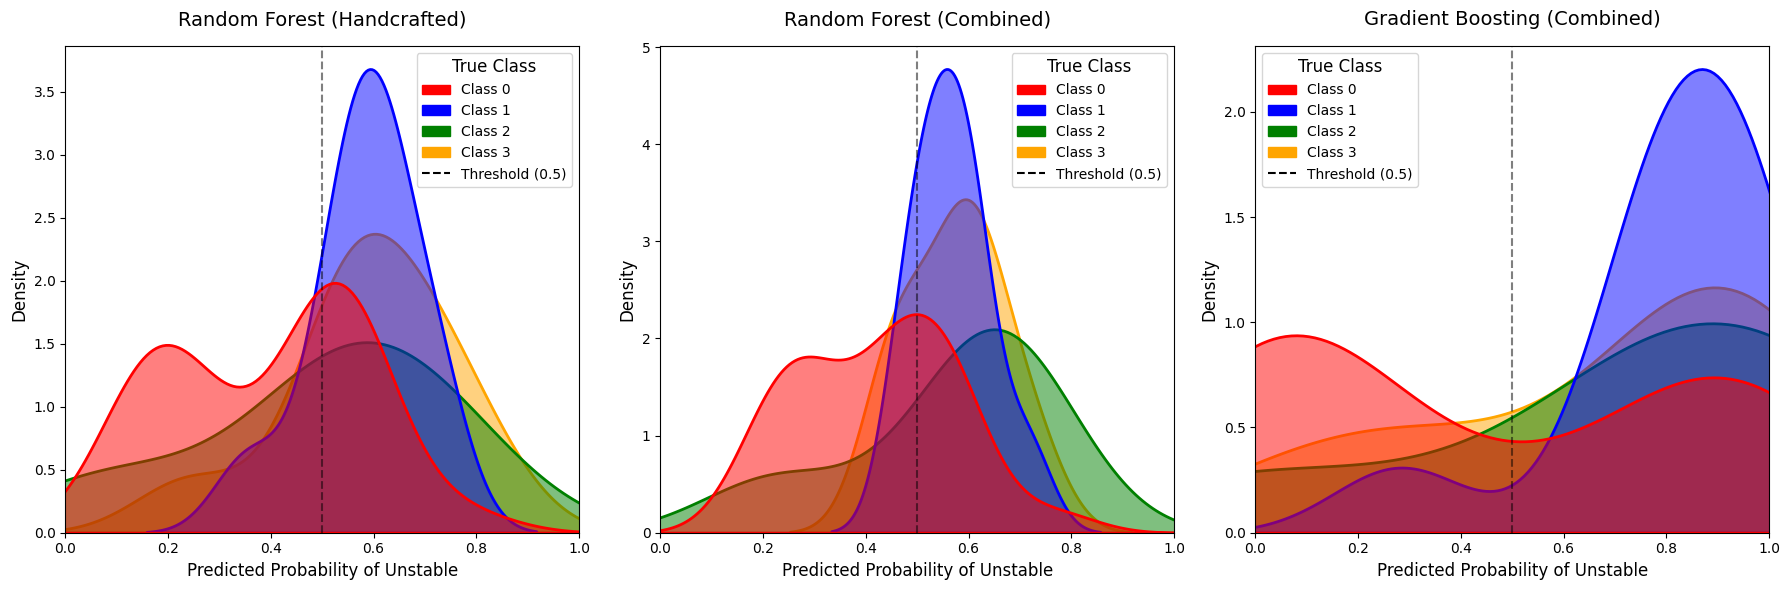

In [13]:
models_to_plot = [
    ('Random Forest (Handcrafted)', 'prob_RandomForest_Handcrafted'),
    ('Random Forest (Combined)', 'prob_RandomForest_Combined'),
    ('Gradient Boosting (Combined)', 'prob_GradientBoosting_Combined')
]

# Define explicit colors and labels for classes so the legend is stable
class_colors = {0: 'red', 1: 'blue', 2: 'green', 3: 'orange'}
class_labels = {0: 'Class 0', 1: 'Class 1', 2: 'Class 2', 3: 'Class 3'}

fig, axes = plt.subplots(1, len(models_to_plot), figsize=(6 * len(models_to_plot), 6))

for ax, (title, prob_col) in zip(axes, models_to_plot):
    if prob_col not in df.columns:
        print(f"Column {prob_col} not found.")
        continue

    # Use the explicit palette mapping so colors are controlled
    sns.kdeplot(
        data=df, x=prob_col, hue='y_true_4cls', fill=True, 
        common_norm=False, alpha=0.5, linewidth=2, ax=ax, palette=class_colors
    )

    ax.set_title(title, fontsize=14, pad=15)
    ax.set_xlabel("Predicted Probability of Unstable", fontsize=12)
    ax.set_ylabel("Density", fontsize=12)
    ax.set_xlim(0, 1)
    ax.axvline(0.5, color='black', linestyle='--', alpha=0.5, label='Threshold (0.5)')

    # Build a custom legend with specified colors and class labels
    from matplotlib.patches import Patch
    from matplotlib.lines import Line2D
    unique_classes = sorted(df['y_true_4cls'].dropna().unique())
    legend_handles = [Patch(color=class_colors.get(int(c), 'gray'), label=class_labels.get(int(c), str(c))) for c in unique_classes]
    # add threshold line to legend
    threshold_handle = Line2D([0], [0], color='black', linestyle='--')
    legend_handles.append(threshold_handle)
    legend_labels = [class_labels.get(int(c), str(c)) for c in unique_classes] + ['Threshold (0.5)']
    ax.legend(legend_handles, legend_labels, title='True Class', fontsize=10, title_fontsize=12)

plt.tight_layout()
plt.show()

y_pred_RandomForest_Combined


,Total Subjects,Misclassified,Error Rate (%)
dataset,,,
kiel,5,3,60.0
omnia_park,12,5,41.7
wearpd,24,6,25.0
pd_phone,9,1,11.1


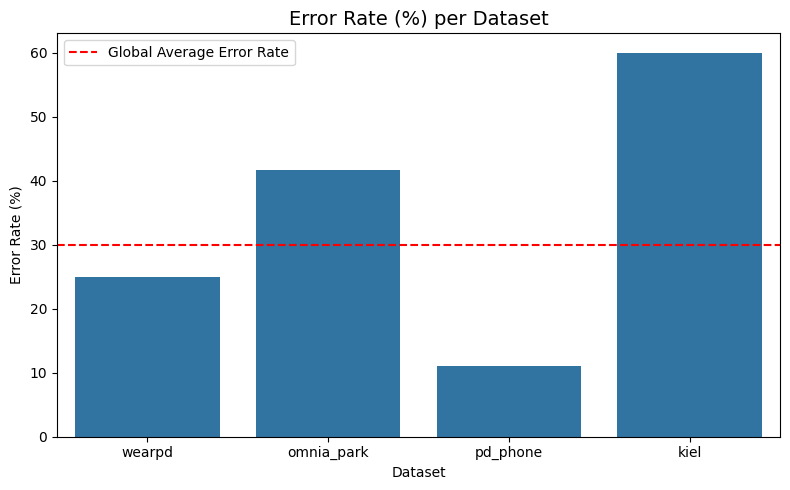

In [14]:
# Seleziona il modello "campione" per cui vuoi fare l'analisi degli errori
target_pred_col = 'y_pred_RandomForest_Combined'

if target_pred_col in df.columns:
    # Filtra i misclassificati
    errors_df = df[df['y_true'] != df[target_pred_col]]
    
    # Calcola Statistiche per Dataset
    total_per_dataset = df['dataset'].value_counts().rename("Total Subjects")
    errors_per_dataset = errors_df['dataset'].value_counts().rename("Misclassified")
    
    # Unisce in un unico DataFrame
    audit_df = pd.concat([total_per_dataset, errors_per_dataset], axis=1).fillna(0)
    audit_df['Misclassified'] = audit_df['Misclassified'].astype(int)
    audit_df['Error Rate (%)'] = (audit_df['Misclassified'] / audit_df['Total Subjects'] * 100).round(1)
    
    print(f"{target_pred_col}")
    display(audit_df.sort_values(by='Error Rate (%)', ascending=False))
    
    # Plot dell'errore per dataset
    plt.figure(figsize=(8, 5))
    sns.barplot(x=audit_df.index, y=audit_df['Error Rate (%)'])
    plt.title("Error Rate (%) per Dataset", fontsize=14)
    plt.ylabel("Error Rate (%)")
    plt.xlabel("Dataset")
    plt.axhline(audit_df['Misclassified'].sum() / audit_df['Total Subjects'].sum() * 100, 
                color='red', linestyle='--', label='Global Average Error Rate')
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print(f"Column {target_pred_col} not found.")